In [25]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# Lab | Natural Language Processing
### SMS: SPAM or HAM

### Let's prepare the environment

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

- Read Data for the Fraudulent Email Kaggle Challenge
- Reduce the training set to speead up development. 

In [4]:
## Read Data for the Fraudulent Email Kaggle Challenge
data = pd.read_csv("../data/kg_train.csv",encoding='latin-1')

# Reduce the training set to speed up development. 
# Modify for final system
data = data.head(1000)
print(data.shape)
data.fillna("",inplace=True)

(1000, 2)


### Let's divide the training and test set into two partitions

In [5]:
# Your code
from sklearn.model_selection import train_test_split

data_train, data_val = train_test_split(data, test_size=0.2, random_state=42, stratify=data['label'])

print(f"Training set size : {data_train.shape}")
print(f"Validation set size: {data_val.shape}")
print(f"\nLabel distribution in training set:")
print(data_train['label'].value_counts())
print(f"\nLabel distribution in validation set:")
print(data_val['label'].value_counts())

Training set size : (800, 2)
Validation set size: (200, 2)

Label distribution in training set:
label
0    446
1    354
Name: count, dtype: int64

Label distribution in validation set:
label
0    112
1     88
Name: count, dtype: int64


## Data Preprocessing

In [6]:
import string
from nltk.corpus import stopwords
print(string.punctuation)
print(stopwords.words("english")[100:110])
from nltk.stem.snowball import SnowballStemmer
snowball = SnowballStemmer('english')

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
['needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on']


## Now, we have to clean the html code removing words

- First we remove inline JavaScript/CSS
- Then we remove html comments. This has to be done before removing regular tags since comments can contain '>' characters
- Next we can remove the remaining tags

In [7]:
# Your code
import re

def remove_html(text):
    """Remove HTML tags, inline JS/CSS, and comments from text."""
    # Remove inline JavaScript / CSS
    text = re.sub(r'<(script|style)[^>]*>[\s\S]*?<\/\1>', ' ', text, flags=re.IGNORECASE)
    # Remove HTML comments (must come before tag removal)
    text = re.sub(r'<!--.*?-->', ' ', text, flags=re.DOTALL)
    # Remove remaining HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    return text

# Quick sanity check
sample = "<html><script>alert('hi')</script><p>Hello <b>World</b>!</p><!-- comment --></html>"
print(remove_html(sample))

   Hello  World !   


- Remove all the special characters
    
- Remove numbers
    
- Remove all single characters
 
- Remove single characters from the start

- Substitute multiple spaces with single space

- Remove prefixed 'b'

- Convert to Lowercase

In [8]:
# Your code
def clean_text(text):
    """Full text cleaning pipeline."""
    # Step 1: Remove HTML
    text = remove_html(text)
    # Step 2: Remove special characters (keep only letters and spaces)
    text = re.sub(r'\W', ' ', text)
    # Step 3: Remove numbers
    text = re.sub(r'\d+', ' ', text)
    # Step 4: Remove single characters from the start
    text = re.sub(r'^\s*\b\w\b\s*', ' ', text)
    # Step 5: Remove all single characters
    text = re.sub(r'\s+\w\s+', ' ', text)
    # Step 6: Substitute multiple spaces with a single space
    text = re.sub(r'\s+', ' ', text)
    # Step 7: Remove prefixed 'b' (artifact from bytes representation)
    text = re.sub(r'^b\s+', '', text)
    # Step 8: Convert to lowercase
    text = text.lower().strip()
    return text

# Apply to both splits
data_train = data_train.copy()
data_val   = data_val.copy()

data_train['cleaned_text'] = data_train['text'].apply(clean_text)
data_val['cleaned_text']   = data_val['text'].apply(clean_text)

data_train[['text', 'cleaned_text']].head(3)

,text,cleaned_text
442,Dear=2C Good day hope fine=2Cdear am writting ...,dear good day hope fine cdear am writting this...
962,FROM MR HENRY KABORETHE CHIEF AUDITOR INCHARGE...,from mr henry kaborethe chief auditor incharge...
971,Will do.,will do


## Now let's work on removing stopwords
Remove the stopwords.

In [9]:
# Your code
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

data_train['no_stop_text'] = data_train['cleaned_text'].apply(remove_stopwords)
data_val['no_stop_text']   = data_val['cleaned_text'].apply(remove_stopwords)

data_train[['cleaned_text', 'no_stop_text']].head(3)

,cleaned_text,no_stop_text
442,dear good day hope fine cdear am writting this...,dear good day hope fine cdear writting mail du...
962,from mr henry kaborethe chief auditor incharge...,mr henry kaborethe chief auditor inchargeforei...
971,will do,


## Tame Your Text with Lemmatization
Break sentences into words, then use lemmatization to reduce them to their base form (e.g., "running" becomes "run"). See how this creates cleaner data for analysis!

In [10]:
# Your code
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words]
    return ' '.join(words)

data_train['preprocessed_text'] = data_train['no_stop_text'].apply(lemmatize_text)
data_val['preprocessed_text']   = data_val['no_stop_text'].apply(lemmatize_text)

data_train[['no_stop_text', 'preprocessed_text']].head(3)

,no_stop_text,preprocessed_text
442,dear good day hope fine cdear writting mail du...,dear good day hope fine cdear writting mail du...
962,mr henry kaborethe chief auditor inchargeforei...,mr henry kaborethe chief auditor inchargeforei...
971,,


## Bag Of Words
Let's get the 10 top words in ham and spam messages (**EXPLORATORY DATA ANALYSIS**)

Top 10 SPAM words: [('money', 761), ('account', 674), ('u', 631), ('bank', 615), ('fund', 600), ('e', 524), ('transaction', 435), ('business', 412), ('country', 401), ('nbsp', 387)]
Top 10 HAM  words: [('â', 103), ('state', 97), ('president', 95), ('would', 92), ('mr', 90), ('obama', 80), ('percent', 80), ('call', 77), ('work', 72), ('time', 70)]


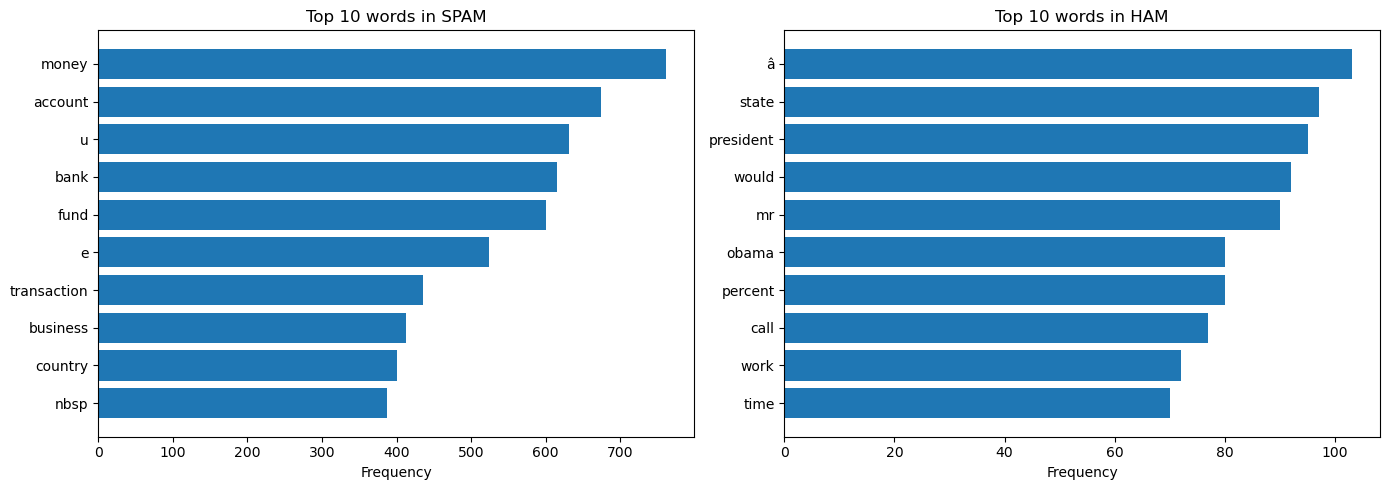

In [11]:
# Your code
from collections import Counter

def top_words(df, label, n=10):
    subset = df[df['label'] == label]['preprocessed_text']
    all_words = ' '.join(subset).split()
    return Counter(all_words).most_common(n)

top_spam = top_words(data_train, label=1)
top_ham  = top_words(data_train, label=0)

print("Top 10 SPAM words:", top_spam)
print("Top 10 HAM  words:", top_ham)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, top, title in zip(axes, [top_spam, top_ham], ['SPAM', 'HAM']):
    words, counts = zip(*top)
    ax.barh(words[::-1], counts[::-1])
    ax.set_title(f'Top 10 words in {title}')
    ax.set_xlabel('Frequency')
plt.tight_layout()
plt.show()

## Extra features

In [12]:
# We add to the original dataframe two additional indicators (money symbols and suspicious words).
money_simbol_list = "|".join(["euro","dollar","pound","€",r"\$"])
suspicious_words = "|".join(["free","cheap","sex","money","account","bank","fund","transfer","transaction","win","deposit","password"])

data_train['money_mark'] = data_train['preprocessed_text'].str.contains(money_simbol_list)*1
data_train['suspicious_words'] = data_train['preprocessed_text'].str.contains(suspicious_words)*1
data_train['text_len'] = data_train['preprocessed_text'].apply(lambda x: len(x)) 

data_val['money_mark'] = data_val['preprocessed_text'].str.contains(money_simbol_list)*1
data_val['suspicious_words'] = data_val['preprocessed_text'].str.contains(suspicious_words)*1
data_val['text_len'] = data_val['preprocessed_text'].apply(lambda x: len(x)) 

data_train.head()

,text,label,cleaned_text,no_stop_text,preprocessed_text,money_mark,suspicious_words,text_len
442,Dear=2C Good day hope fine=2Cdear am writting ...,1,dear good day hope fine cdear am writting this...,dear good day hope fine cdear writting mail du...,dear good day hope fine cdear writting mail du...,1,1,1002
962,FROM MR HENRY KABORETHE CHIEF AUDITOR INCHARGE...,1,from mr henry kaborethe chief auditor incharge...,mr henry kaborethe chief auditor inchargeforei...,mr henry kaborethe chief auditor inchargeforei...,0,1,2015
971,Will do.,0,will do,,,0,0,0
190,FROM THE DESK OF DR.ADAMU ISMALERAUDITING AND...,1,from the desk of dr adamu ismalerauditing and ...,desk dr adamu ismalerauditing accounting manag...,desk dr adamu ismalerauditing accounting manag...,1,1,383
551,"Dear Friend, My name is LOI C.ESTRADA,The wife...",1,dear friend my name is loi estrada the wife of...,dear friend name loi estrada wife mr josephest...,dear friend name loi estrada wife mr josephest...,1,1,1475


## How would work the Bag of Words with Count Vectorizer concept?

In [13]:
# Your code
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(max_features=5000)

X_train_bow = count_vectorizer.fit_transform(data_train['preprocessed_text'])
X_val_bow   = count_vectorizer.transform(data_val['preprocessed_text'])

print("BoW Training matrix shape  :", X_train_bow.shape)
print("BoW Validation matrix shape:", X_val_bow.shape)

# Show a few feature names
print("\nSample feature names:", count_vectorizer.get_feature_names_out()[:20])

BoW Training matrix shape  : (800, 5000)
BoW Validation matrix shape: (200, 5000)

Sample feature names: ['___________________________________________________________________________mail'
 '_________________________________________________________________dã'
 '____________________________________________________________charle'
 '_nextpart_' '_part_' 'aa' 'aal' 'aat' 'ab' 'abacha' 'abandoned' 'abedin'
 'abidjan' 'abilateral' 'ability' 'able' 'abm' 'abn' 'aboard' 'abroad']


## TF-IDF

- Load the vectorizer

- Vectorize all dataset

- print the shape of the vetorized dataset

In [14]:
# Your code
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(data_train['preprocessed_text'])
X_val_tfidf   = tfidf_vectorizer.transform(data_val['preprocessed_text'])

print("TF-IDF Training matrix shape  :", X_train_tfidf.shape)
print("TF-IDF Validation matrix shape:", X_val_tfidf.shape)

# Show a few feature names
print("\nSample feature names:", tfidf_vectorizer.get_feature_names_out()[:20])

TF-IDF Training matrix shape  : (800, 5000)
TF-IDF Validation matrix shape: (200, 5000)

Sample feature names: ['___________________________________________________________________________mail'
 '_________________________________________________________________dã'
 '____________________________________________________________charle'
 '_nextpart_' '_part_' 'aa' 'aal' 'aat' 'ab' 'abacha' 'abandoned' 'abedin'
 'abidjan' 'abilateral' 'ability' 'able' 'abm' 'abn' 'aboard' 'abroad']


## And the Train a Classifier?

In [15]:
# Your code
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

y_train = data_train['label']
y_val   = data_val['label']

# Train on TF-IDF features
clf = MultinomialNB()
clf.fit(X_train_tfidf, y_train)

y_pred = clf.predict(X_val_tfidf)

print("=== MultinomialNB with TF-IDF ===")
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print(classification_report(y_val, y_pred, target_names=['HAM', 'SPAM']))

=== MultinomialNB with TF-IDF ===
Accuracy: 0.9850
              precision    recall  f1-score   support

         HAM       1.00      0.97      0.99       112
        SPAM       0.97      1.00      0.98        88

    accuracy                           0.98       200
   macro avg       0.98      0.99      0.98       200
weighted avg       0.99      0.98      0.99       200



### Extra Task - Implement a SPAM/HAM classifier

https://www.kaggle.com/t/b384e34013d54d238490103bc3c360ce

The classifier can not be changed!!! It must be the MultinimialNB with default parameters!

Your task is to **find the most relevant features**.

For example, you can test the following options and check which of them performs better:
- Using "Bag of Words" only
- Using "TF-IDF" only
- Bag of Words + extra flags (money_mark, suspicious_words, text_len)
- TF-IDF + extra flags


You can work with teams of two persons (recommended).

In [19]:
# Your code
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score
import scipy.sparse as sp

# ── Extra feature matrices ──────────────────────────────────────────────────
extra_cols = ['money_mark', 'suspicious_words', 'text_len']

# Scale text_len to [0,1] so it's compatible with MultinomialNB (needs non-negative)
scaler = MinMaxScaler()
X_train_extra = scaler.fit_transform(data_train[extra_cols].values)
X_val_extra   = scaler.transform(data_val[extra_cols].values)

X_train_extra_sp = sp.csr_matrix(X_train_extra)
X_val_extra_sp   = sp.csr_matrix(X_val_extra)

# ── Configurations to test ──────────────────────────────────────────────────
experiments = {
    "BoW only":          (X_train_bow,                              X_val_bow),
    "TF-IDF only":       (X_train_tfidf,                           X_val_tfidf),
    "BoW + extra flags": (sp.hstack([X_train_bow,   X_train_extra_sp]),
                          sp.hstack([X_val_bow,     X_val_extra_sp])),
    "TF-IDF + extra flags": (sp.hstack([X_train_tfidf, X_train_extra_sp]),
                              sp.hstack([X_val_tfidf,   X_val_extra_sp])),
}

results = []
for name, (X_tr, X_vl) in experiments.items():
    model = MultinomialNB()
    model.fit(X_tr, y_train)
    preds = model.predict(X_vl)
    acc   = accuracy_score(y_val, preds)
    f1    = f1_score(y_val, preds)
    results.append({'Configuration': name, 'Accuracy': acc, 'F1-Score (SPAM)': f1})
    print(f"{name:30s}  Accuracy={acc:.4f}  F1={f1:.4f}")

results_df = pd.DataFrame(results).sort_values('F1-Score (SPAM)', ascending=False)
print("\n", results_df.to_string(index=False))

BoW only                        Accuracy=0.9800  F1=0.9778
TF-IDF only                     Accuracy=0.9850  F1=0.9832
BoW + extra flags               Accuracy=0.9800  F1=0.9778
TF-IDF + extra flags            Accuracy=0.9650  F1=0.9617

        Configuration  Accuracy  F1-Score (SPAM)
         TF-IDF only     0.985         0.983240
            BoW only     0.980         0.977778
   BoW + extra flags     0.980         0.977778
TF-IDF + extra flags     0.965         0.961749


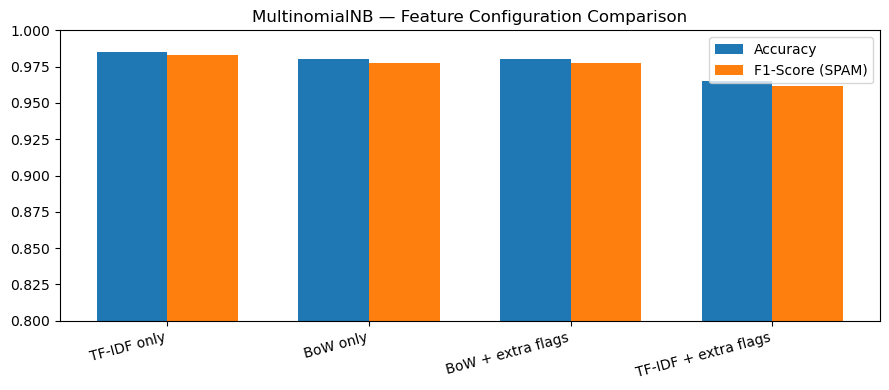

In [20]:
# ── Plot comparison ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(results_df))
width = 0.35
ax.bar([i - width/2 for i in x], results_df['Accuracy'],        width, label='Accuracy')
ax.bar([i + width/2 for i in x], results_df['F1-Score (SPAM)'], width, label='F1-Score (SPAM)')
ax.set_xticks(list(x))
ax.set_xticklabels(results_df['Configuration'], rotation=15, ha='right')
ax.set_ylim(0.8, 1.0)
ax.set_title('MultinomialNB — Feature Configuration Comparison')
ax.legend()
plt.tight_layout()
plt.show()